# Hiperparametros — AC CTRL → Reactor Ciclopentanol
Se ajusta la busqueda en mejores resultados



## 1. Instalación e Imports

In [1]:
import os
import random
import numpy as np
import torch
import wandb
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Clonar desde Github:
!git clone https://github.com/valeriaeskenazi/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning.git
PROJECT_PATH = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4'
sys.path.append(PROJECT_PATH)

Cloning into 'Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning'...
remote: Enumerating objects: 1761, done.
remote: Counting objects: 100% (321/321), done.
remote: Compressing objects: 100% (216/216), done.
remote: Total 1761 (delta 193), reused 227 (delta 104), pack-reused 1440 (from 1)
Receiving objects: 100% (1761/1761), 41.62 MiB | 18.47 MiB/s, done.
Resolving deltas: 100% (1057/1057), done.


In [3]:
from Environment.Simulation_Env.Reactor_CSTR import CSTRSimulator
from Environment.Simulation_Env.Reactor_Cyclopentanol import CyclopentanolReactor
from Environment.PIDControlEnv_simple import PIDControlEnv_Simple
from Environment.Simulation_Env.SimulationEnv import SimulationPIDEnv
from Agente.Actor_Critic.train_AC import ACTrainer
from Agente.Actor_Critic.algorithm_AC import ACAgent
from Agente.memory import SimpleReplayBuffer
from Agente.Actor_Critic.transfer_learning_AC import setup_transfer_learning, freeze_layers
from Aux.PIDComponents_PID import PIDController
from Aux.PIDComponents_time import ResponseTimeDetector
from Aux.PIDComponentes_translate import ApplyAction

print('Imports completados')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

Imports completados
PyTorch: 2.10.0+cpu
Device: CPU


## 2. Corrida larga: sweep 5k from scratch

In [20]:
# ============ CONFIG PRODUCCIÓN — solar-sweep-15 ganador ============

WANDB_ENTITY  = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_AC_Cyclopentanol_Prod'
RUN_NAME = 'ac_cyclopentanol_5k_V3'

N_EPISODES = 5000
EVAL_FREQUENCY = 100
LOG_FREQUENCY = 100
SAVE_FREQUENCY = 1000
EARLY_STOPPING_PATIENCE = 20
N_MANIPULABLE_VARS = 2
MANIPULABLE_RANGES = [(0.5, 1.5), (395.0, 420.0)]
ACTUATOR_LIMITS = [(50.0, 800.0), (-8500.0, 0.0)]
DT = 0.01
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED=42

trainer_config_prod = {
    'env_config': {
        'architecture':          'simple',
        'env_type':              'simulation',
        'action_type':           'continuous',
        'n_manipulable_vars':    N_MANIPULABLE_VARS,
        'manipulable_ranges':    MANIPULABLE_RANGES,
        'manipulable_setpoints': None,
        'dt_usuario':            DT,
        'max_steps':             100,
        'max_time_detector':     3.0,
        'reward_dead_band':      0.05,
        'delta_percent_ctrl':    0.05,
        'reward_weights':        {'error': 1.0, 'tiempo': 0.001, 'overshoot': 5.0, 'energy': 0.0},
        'pid_limits':            [(0.01, 500.0), (0.0, 5000.0), (0.0, 10.0)],
        'agent_controller_config': {'agent_type': 'continuous'},
        'env_type_config': {
            'dt': DT,
            'control_limits': (ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1])
        },
        'stability_config': {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio':   0.3,
            'max_abrupt_change_ratio':  0.05,
            'abrupt_change_threshold':  0.2,
        },
    },
    'agent_ctrl_config': {
        'algorithm':    'ac',
        'state_dim':    10,
        'action_dim':   6,
        'n_vars':       2,
        'action_type':  'continuous',
        'hidden_dims':  (256, 128, 64),
        'lr_actor':     3e-05,
        'lr_critic':    1e-03,
        'gamma':        0.99,
        'entropy_coef': 0.001,
        'batch_size':   128,
        'buffer_size':  50000,
        'warmup_steps': 500,
        'device':       DEVICE,
        'seed':         SEED,
    },
    'n_episodes':                    N_EPISODES,
    'eval_frequency':                EVAL_FREQUENCY,
    'log_frequency':                 LOG_FREQUENCY,
    'save_frequency':                SAVE_FREQUENCY,
    'checkpoint_dir':                f'checkpoints/{RUN_NAME}',
    'early_stopping_patience':       EARLY_STOPPING_PATIENCE,
    'early_stopping_min_delta_pct':  0.01,
    'use_wandb': True,
}



In [5]:
# ============ CREAR ============
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

reactor_prod = CyclopentanolReactor(
    dt=DT,
    control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1])
)
trainer_prod = ACTrainer(trainer_config_prod)
trainer_prod.env.proceso.connect_external_process(reactor_prod)
trainer_prod.env.pid_controllers[0].output_limits = ACTUATOR_LIMITS[0]
trainer_prod.env.pid_controllers[1].output_limits = ACTUATOR_LIMITS[1]

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu


In [6]:
# ============ FIX: PID bias en estado estacionario ============
_original_reset = trainer_prod.env.reset

def reset_with_bias(*args, **kwargs):
    result = _original_reset(*args, **kwargs)
    for i, pid in enumerate(trainer_prod.env.pid_controllers):
        if i == 0:  # CB → v
            pid.kp = 50.0
            pid.ki = 500.0
            pid.kd = 0.01
            pid.integral = reactor_prod.v_ss / pid.ki
        elif i == 1:  # T → QK
            pid.kp = 10.0
            pid.ki = 1000.0
            pid.kd = 0.0
            pid.integral = reactor_prod.QK_ss / pid.ki
    return result

trainer_prod.env.reset = reset_with_bias
print(f'PID bias configurado: v_ss={reactor_prod.v_ss:.1f}, QK_ss={reactor_prod.QK_ss:.1f}')

PID bias configurado: v_ss=188.3, QK_ss=-7000.0


In [7]:
# ============ ENTRENAR ============
wandb.init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY,
    name=RUN_NAME,
    tags=['ac', 'produccion', 'cyclopentanol', 'from_scratch'],
    config=trainer_config_prod,
)

trainer_prod.train()

wandb.log({
    'final_eval_reward': trainer_prod.best_reward,
    'total_episodes': len(trainer_prod.episode_rewards),
})
wandb.finish()
print(f'Producción completada: {RUN_NAME}')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ve326684 (ve326684-universidad-ort-uruguay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

wandb: Adding directory to artifact (checkpoints/ac_cyclopentanol_5k_V3)... Done. 0.0s


Evaluación: Reward promedio = -0.07
  Sin mejora: 5/20
AC Agent guardado en: checkpoints/ac_cyclopentanol_5k_V3/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 700/5000
  Reward: -0.07 | Length: 101
  Actor Loss: 0.1065 | Critic Loss: 21.4496
  Advantage mean: 0.0565
Evaluación: Reward promedio = -0.16
  Sin mejora: 6/20

Episodio 800/5000
  Reward: -0.01 | Length: 101
  Actor Loss: 0.1366 | Critic Loss: 12.6154
  Advantage mean: 0.0649
Evaluación: Reward promedio = -0.52
  Sin mejora: 7/20

Episodio 900/5000
  Reward: -0.11 | Length: 101
  Actor Loss: 0.1066 | Critic Loss: 8.9338
  Advantage mean: 0.0667
Evaluación: Reward promedio = -0.17
  Sin mejora: 8/20

Episodio 1000/5000
  Reward: -2.04 | Length: 101
  Actor Loss: 0.4954 | Critic Loss: 55.1249
  Advantage mean: 0.1654


wandb: Adding directory to artifact (checkpoints/ac_cyclopentanol_5k_V3)... Done. 0.0s


Evaluación: Reward promedio = -0.13
  Sin mejora: 9/20
AC Agent guardado en: checkpoints/ac_cyclopentanol_5k_V3/agent_ctrl_ep1000.pt
Checkpoint guardado: ep1000

Episodio 1100/5000
  Reward: -0.02 | Length: 101
  Actor Loss: 0.2917 | Critic Loss: 31.1747
  Advantage mean: 0.1331
Evaluación: Reward promedio = -0.10
  Sin mejora: 10/20

Episodio 1200/5000
  Reward: -0.08 | Length: 101
  Actor Loss: 0.1372 | Critic Loss: 62.4701
  Advantage mean: 0.0673
Evaluación: Reward promedio = -0.13
  Sin mejora: 11/20

Episodio 1300/5000
  Reward: -0.38 | Length: 101
  Actor Loss: -0.0184 | Critic Loss: 12.4804
  Advantage mean: -0.0112
Evaluación: Reward promedio = -0.13
  Sin mejora: 12/20

Episodio 1400/5000
  Reward: -0.03 | Length: 101
  Actor Loss: 0.4140 | Critic Loss: 50.3998
  Advantage mean: 0.1168
Evaluación: Reward promedio = -0.16
  Sin mejora: 13/20


KeyboardInterrupt: 

## 7. Evaluación del Mejor Agente

In [7]:
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_Cyclopentanol_Prod/model_ac_cyclopentanol_5k_V3:latest')
artifact_dir = artifact.download()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb:   2 of 2 files downloaded.  


In [10]:
# ============ CARGAR MEJOR AGENTE (transfer) ============
BEST_CHECKPOINT = '/content/artifacts/model_ac_cyclopentanol_5k_V3:v3/agent_ctrl_best.pt'

agent_eval = ACAgent(
    state_dim=10, action_dim=6, agent_role='ctrl', n_vars=2,
    hidden_dims=(256, 128, 64),
    lr_actor=3e-05, lr_critic=1e-03,
    gamma=0.99, entropy_coef=0.001,
    batch_size=64, buffer_size=50000, warmup_steps=500,
    device=DEVICE, seed=SEED
)
agent_eval.load(BEST_CHECKPOINT)
print('Agente cargado')

AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_ac_cyclopentanol_5k_V3:v3/agent_ctrl_best.pt
Agente cargado


In [12]:
# ============ EVALUACIÓN MANUAL — LOOP DIRECTO ============
reactor_eval = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))
reactor_eval.reset()

pid_controllers = [
    PIDController(kp=50.0, ki=500.0, kd=0.01, dt=DT, output_limits=ACTUATOR_LIMITS[0]),
    PIDController(kp=10.0, ki=1000.0, kd=0.0,  dt=DT, output_limits=ACTUATOR_LIMITS[1]),
]
pid_controllers[0].integral = reactor_eval.v_ss / pid_controllers[0].ki
pid_controllers[1].integral = reactor_eval.QK_ss / pid_controllers[1].ki

apply_action = ApplyAction(
    delta_percent_ctrl=0.2,
    pid_limits=[(0.01, 500.0), (0.0, 5000.0), (0.0, 10.0)],
    manipulable_ranges=MANIPULABLE_RANGES
)

CB_sp, T_sp = 0.95, 410.0
sps = [CB_sp, T_sp]
pvs = reactor_eval.get_initial_pvs()

error_integral = [0.0, 0.0]
error_prev = [sps[i] - pvs[i] for i in range(2)]

traj_CB, traj_T = [pvs[0]], [pvs[1]]

N_AGENT_STEPS = 20
INNER_STEPS = 500

for step in range(N_AGENT_STEPS):
    errors = [sps[i] - pvs[i] for i in range(2)]
    for i in range(2):
        error_integral[i] += errors[i] * DT
    error_derivative = [errors[i] - error_prev[i] for i in range(2)]
    error_prev = errors.copy()

    state = np.array([
        pvs[0], sps[0], errors[0], error_integral[0], error_derivative[0],
        pvs[1], sps[1], errors[1], error_integral[1], error_derivative[1],
    ], dtype=np.float32)

    action = agent_eval.select_action(state, training=False)
    pid_params = apply_action.translate(
        action=action, agent_type='ctrl', action_type='continuous',
        current_values=[(p.kp, p.ki, p.kd) for p in pid_controllers]
    )
    for i, (kp, ki, kd) in enumerate(pid_params):
        pid_controllers[i].kp = kp
        pid_controllers[i].ki = ki
        pid_controllers[i].kd = kd

    for _ in range(INNER_STEPS):
        meas = reactor_eval.get_measurements()
        v_out = pid_controllers[0].compute(setpoint=sps[0], process_value=meas['CB'])
        qk_out = pid_controllers[1].compute(setpoint=sps[1], process_value=meas['T'])
        pvs_new = reactor_eval.simulate_step_multi([v_out, qk_out], DT)

    pvs = [pvs_new[0], pvs_new[1]]
    traj_CB.append(pvs[0])
    traj_T.append(pvs[1])
    print(f'Step {step+1:2d} | CB={pvs[0]:.4f} | T={pvs[1]:.2f} | '
          f'kp_CB={pid_controllers[0].kp:.4f} ki_CB={pid_controllers[0].ki:.2f} | '
          f'kp_T={pid_controllers[1].kp:.4f} ki_T={pid_controllers[1].ki:.2f}')

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
Step  1 | CB=0.9220 | T=411.98 | kp_CB=49.0000 ki_CB=499.00 | kp_T=9.0000 ki_T=999.00
Step  2 | CB=0.9393 | T=412.85 | kp_CB=48.0000 ki_CB=498.00 | kp_T=8.0000 ki_T=998.00
Step  3 | CB=0.9459 | T=413.05 | kp_CB=47.0000 ki_CB=497.00 | kp_T=7.0000 ki_T=997.00
Step  4 | CB=0.9468 | T=413.31 | kp_CB=46.0000 ki_CB=496.00 | kp_T=6.0000 ki_T=996.00
Step  5 | CB=0.9490 | T=413.39 | kp_CB=45.0000 ki_CB=495.00 | kp_T=5.0000 ki_T=995.00
Step  6 | CB=0.9491 | T=413.41 | kp_CB=44.0000 ki_CB=494.00 | kp_T=4.0000 ki_T=994.00
Step  7 | CB=0.9499 | T=413.43 | kp_CB=43.0000 ki_CB=493.00 | kp_T=3.0000 ki_T=993.00
Step  8 | CB=0.9491 | T=413.31 | kp_CB=42.0000 ki_CB=492.00 | kp_T=2.0000 ki_T=992.00
Step  9 

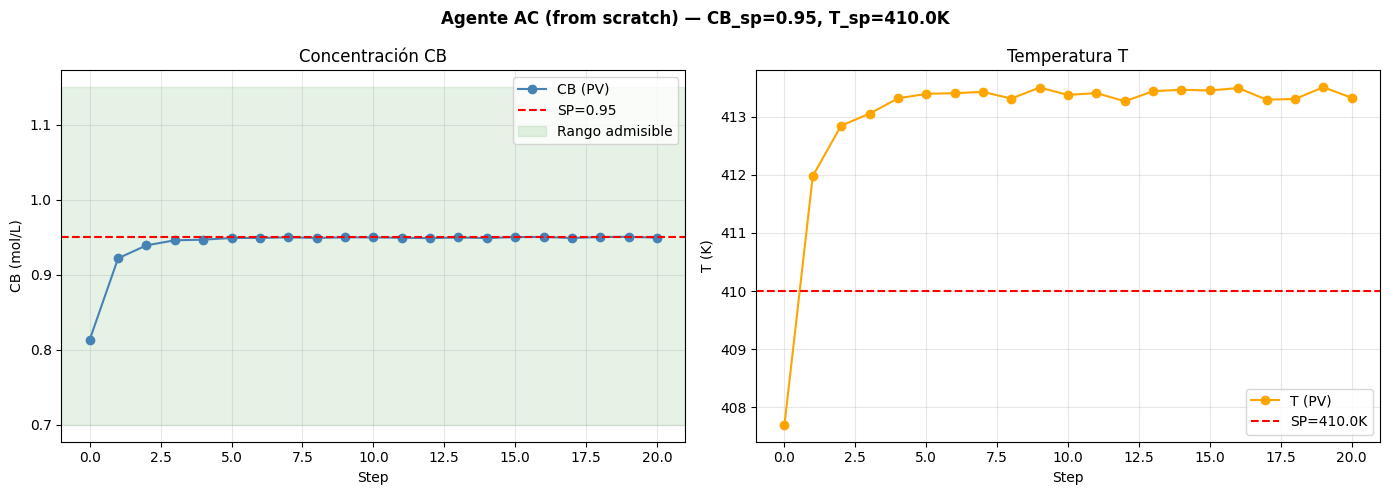

In [13]:
# ============ GRAFICAR ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(traj_CB, marker='o', color='steelblue', label='CB (PV)')
axes[0].axhline(CB_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={CB_sp}')
axes[0].axhspan(0.7, 1.15, alpha=0.1, color='green', label='Rango admisible')
axes[0].set_title('Concentración CB')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('CB (mol/L)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(traj_T, marker='o', color='orange', label='T (PV)')
axes[1].axhline(T_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={T_sp}K')
axes[1].set_title('Temperatura T')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('T (K)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Agente AC (from scratch) — CB_sp={CB_sp}, T_sp={T_sp}K', fontweight='bold')
plt.tight_layout()
plt.savefig('eval_transfer_cyclopentanol.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Comparación con Baselines del Informe 2015

In [14]:
# ============ BASELINE: PID MANUAL DEL INFORME ============
def run_baseline_pid(reactor, CB_sp, T_sp, Kp_CB, Ki_CB, Kd_CB, Kp_T, Ki_T, Kd_T, n_steps=2000):
    """Simula el reactor con PID fijos (baselines del informe 2015)."""
    reactor.reset()
    integral_CB, integral_T = 0.0, 0.0
    prev_err_CB, prev_err_T = 0.0, 0.0
    dt = reactor.dt
    cb_hist, t_hist = [], []

    for _ in range(n_steps):
        meas = reactor.get_measurements()

        err_CB = CB_sp - meas['CB']
        integral_CB += err_CB * dt
        deriv_CB = (err_CB - prev_err_CB) / dt
        v_out = reactor.v_ss + Kp_CB * err_CB + Ki_CB * integral_CB + Kd_CB * deriv_CB
        v_out = np.clip(v_out, 50, 800)
        prev_err_CB = err_CB

        err_T = T_sp - meas['T']
        integral_T += err_T * dt
        deriv_T = (err_T - prev_err_T) / dt
        QK_out = reactor.QK_ss + Kp_T * err_T + Ki_T * integral_T + Kd_T * deriv_T
        QK_out = np.clip(QK_out, -8500, 0)
        prev_err_T = err_T

        pvs = reactor.simulate_step_multi([v_out, QK_out], dt)
        cb_hist.append(pvs[0])
        t_hist.append(pvs[1])

    return cb_hist, t_hist


# ============ CORRER BASELINES ============
CB_sp, T_sp = 0.95, 410.0

reactor_bl = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))

# Ajuste manual (informe sección 4.3)
cb_manual, t_manual = run_baseline_pid(
    reactor_bl, CB_sp, T_sp,
    Kp_CB=100, Ki_CB=1000, Kd_CB=0.01,
    Kp_T=20, Ki_T=2000, Kd_T=0.0
)

# Ziegler-Nichols CB + manual T
cb_zn, t_zn = run_baseline_pid(
    reactor_bl, CB_sp, T_sp,
    Kp_CB=1081.4, Ki_CB=1081.4/0.020, Kd_CB=0,  # ZN sin Kd (mejor resultado del informe)
    Kp_T=20, Ki_T=2000, Kd_T=0.0
)

print(f'Manual:  CB_final={cb_manual[-1]:.4f} (err={abs(cb_manual[-1]-CB_sp):.5f}), T_final={t_manual[-1]:.2f}')
print(f'Z-N:     CB_final={cb_zn[-1]:.4f} (err={abs(cb_zn[-1]-CB_sp):.5f}), T_final={t_zn[-1]:.2f}')

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
Manual:  CB_final=0.9508 (err=0.00084), T_final=413.28
Z-N:     CB_final=0.9506 (err=0.00061), T_final=413.32


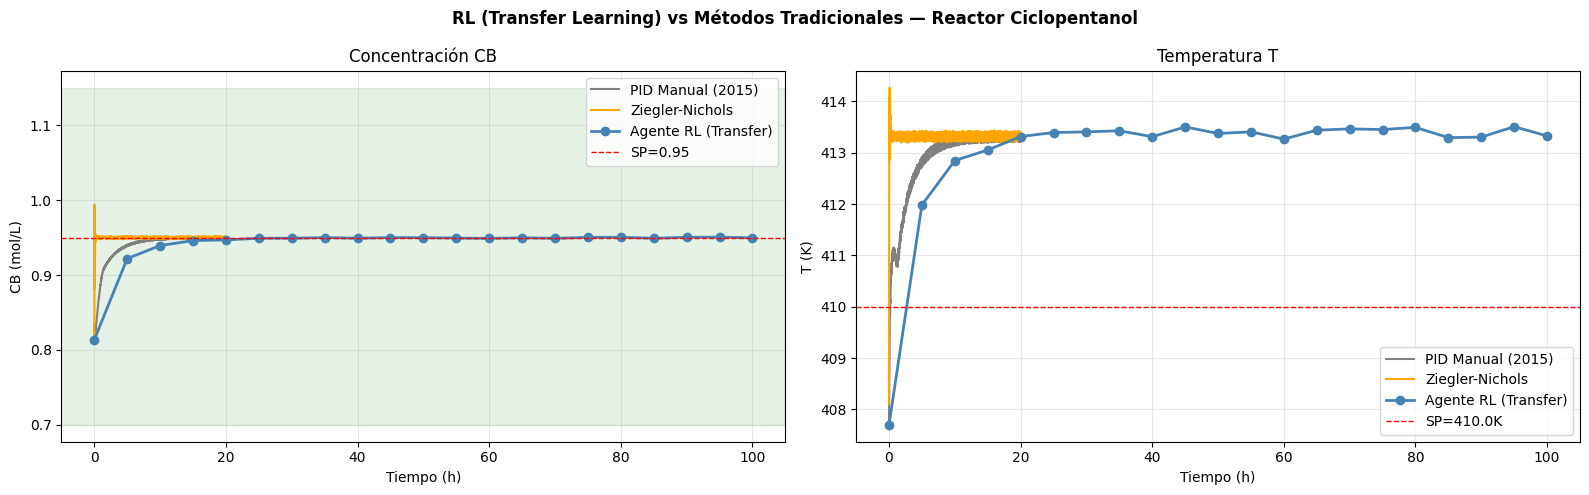

In [15]:
# ============ COMPARAR TODOS ============
time_hours = np.arange(len(cb_manual)) * DT

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# CB
axes[0].plot(time_hours, cb_manual, label='PID Manual (2015)', color='gray', linewidth=1.5)
axes[0].plot(time_hours, cb_zn, label='Ziegler-Nichols', color='orange', linewidth=1.5)
axes[0].plot(np.arange(len(traj_CB)) * (5.0),  # tiempo aprox por step
             traj_CB, label='Agente RL (Transfer)', color='steelblue', linewidth=2, marker='o')
axes[0].axhline(CB_sp, color='red', linestyle='--', linewidth=1, label=f'SP={CB_sp}')
axes[0].axhspan(0.7, 1.15, alpha=0.1, color='green')
axes[0].set_title('Concentración CB')
axes[0].set_xlabel('Tiempo (h)')
axes[0].set_ylabel('CB (mol/L)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# T
axes[1].plot(time_hours, t_manual, label='PID Manual (2015)', color='gray', linewidth=1.5)
axes[1].plot(time_hours, t_zn, label='Ziegler-Nichols', color='orange', linewidth=1.5)
axes[1].plot(np.arange(len(traj_T)) * (5.0),
             traj_T, label='Agente RL (Transfer)', color='steelblue', linewidth=2, marker='o')
axes[1].axhline(T_sp, color='red', linestyle='--', linewidth=1, label=f'SP={T_sp}K')
axes[1].set_title('Temperatura T')
axes[1].set_xlabel('Tiempo (h)')
axes[1].set_ylabel('T (K)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('RL (Transfer Learning) vs Métodos Tradicionales — Reactor Ciclopentanol', fontweight='bold')
plt.tight_layout()
plt.savefig('rl_vs_traditional_cyclopentanol.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Pruebas con otros SP (Grilla)

In [23]:
# ============ GRILLA DE SETPOINTS ============
CB_setpoints = [0.75, 0.85, 0.95, 1.05, 1.10]  # mol/L (rango admisible: 0.7-1.15)
T_setpoints  = [405, 408, 410, 412, 415]        # K

# ============ FUNCIÓN DE EVALUACIÓN ============
eval_config = trainer_config_prod.copy()
eval_config['n_episodes'] = 1
eval_config['use_wandb'] = False
eval_config['checkpoint_dir'] = 'checkpoints/eval_tmp'

reactor_eval2 = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))
trainer_eval = ACTrainer(eval_config)
trainer_eval.env.proceso.connect_external_process(reactor_eval2)
trainer_eval.env.pid_controllers[0].output_limits = ACTUATOR_LIMITS[0]
trainer_eval.env.pid_controllers[1].output_limits = ACTUATOR_LIMITS[1]

# ============ FIX: PID bias en cada reset ============
_original_reset_eval = trainer_eval.env.reset

def reset_eval_with_bias(*args, **kwargs):
    result = _original_reset_eval(*args, **kwargs)
    for i, pid in enumerate(trainer_eval.env.pid_controllers):
        if i == 0:
            pid.kp = 50.0
            pid.ki = 500.0
            pid.kd = 0.01
            pid.integral = reactor_eval2.v_ss / pid.ki
        elif i == 1:
            pid.kp = 10.0
            pid.ki = 1000.0
            pid.kd = 0.0
            pid.integral = reactor_eval2.QK_ss / pid.ki
    return result

trainer_eval.env.reset = reset_eval_with_bias

trainer_eval.agent_ctrl.load(BEST_CHECKPOINT)
print('Agente cargado para evaluación')


def evaluar_sp(trainer, CB_sp, T_sp, max_steps=100):
    state = trainer.env.reset()[0]
    trainer.env.manipulable_setpoints = [CB_sp, T_sp]
    trainer.env._update_errors()
    state = trainer.env._get_observation()

    CB_hist, T_hist = [], []
    done = False
    step = 0

    while not done and step < max_steps:
        action = trainer.agent_ctrl.select_action(state, training=False)
        next_state, reward, terminated, truncated, info = trainer.env.step(action)
        done = terminated or truncated
        CB_hist.append(trainer.env.manipulable_pvs[0])
        T_hist.append(trainer.env.manipulable_pvs[1])
        state = next_state
        step += 1

    return np.array(CB_hist), np.array(T_hist)

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_ac_cyclopentanol_5k_V3:v3/agent_ctrl_best.pt
Agente cargado para evaluación


CB_sp=0.75 → CB_final=0.7437 (err=0.0063) | T_final=410.38 (err=0.38K)
CB_sp=0.85 → CB_final=0.8235 (err=0.0265) | T_final=410.81 (err=0.81K)
CB_sp=0.95 → CB_final=0.8880 (err=0.0620) | T_final=411.40 (err=1.40K)
CB_sp=1.05 → CB_final=0.9306 (err=0.1194) | T_final=412.42 (err=2.42K)
CB_sp=1.1 → CB_final=0.9441 (err=0.1559) | T_final=413.14 (err=3.14K)


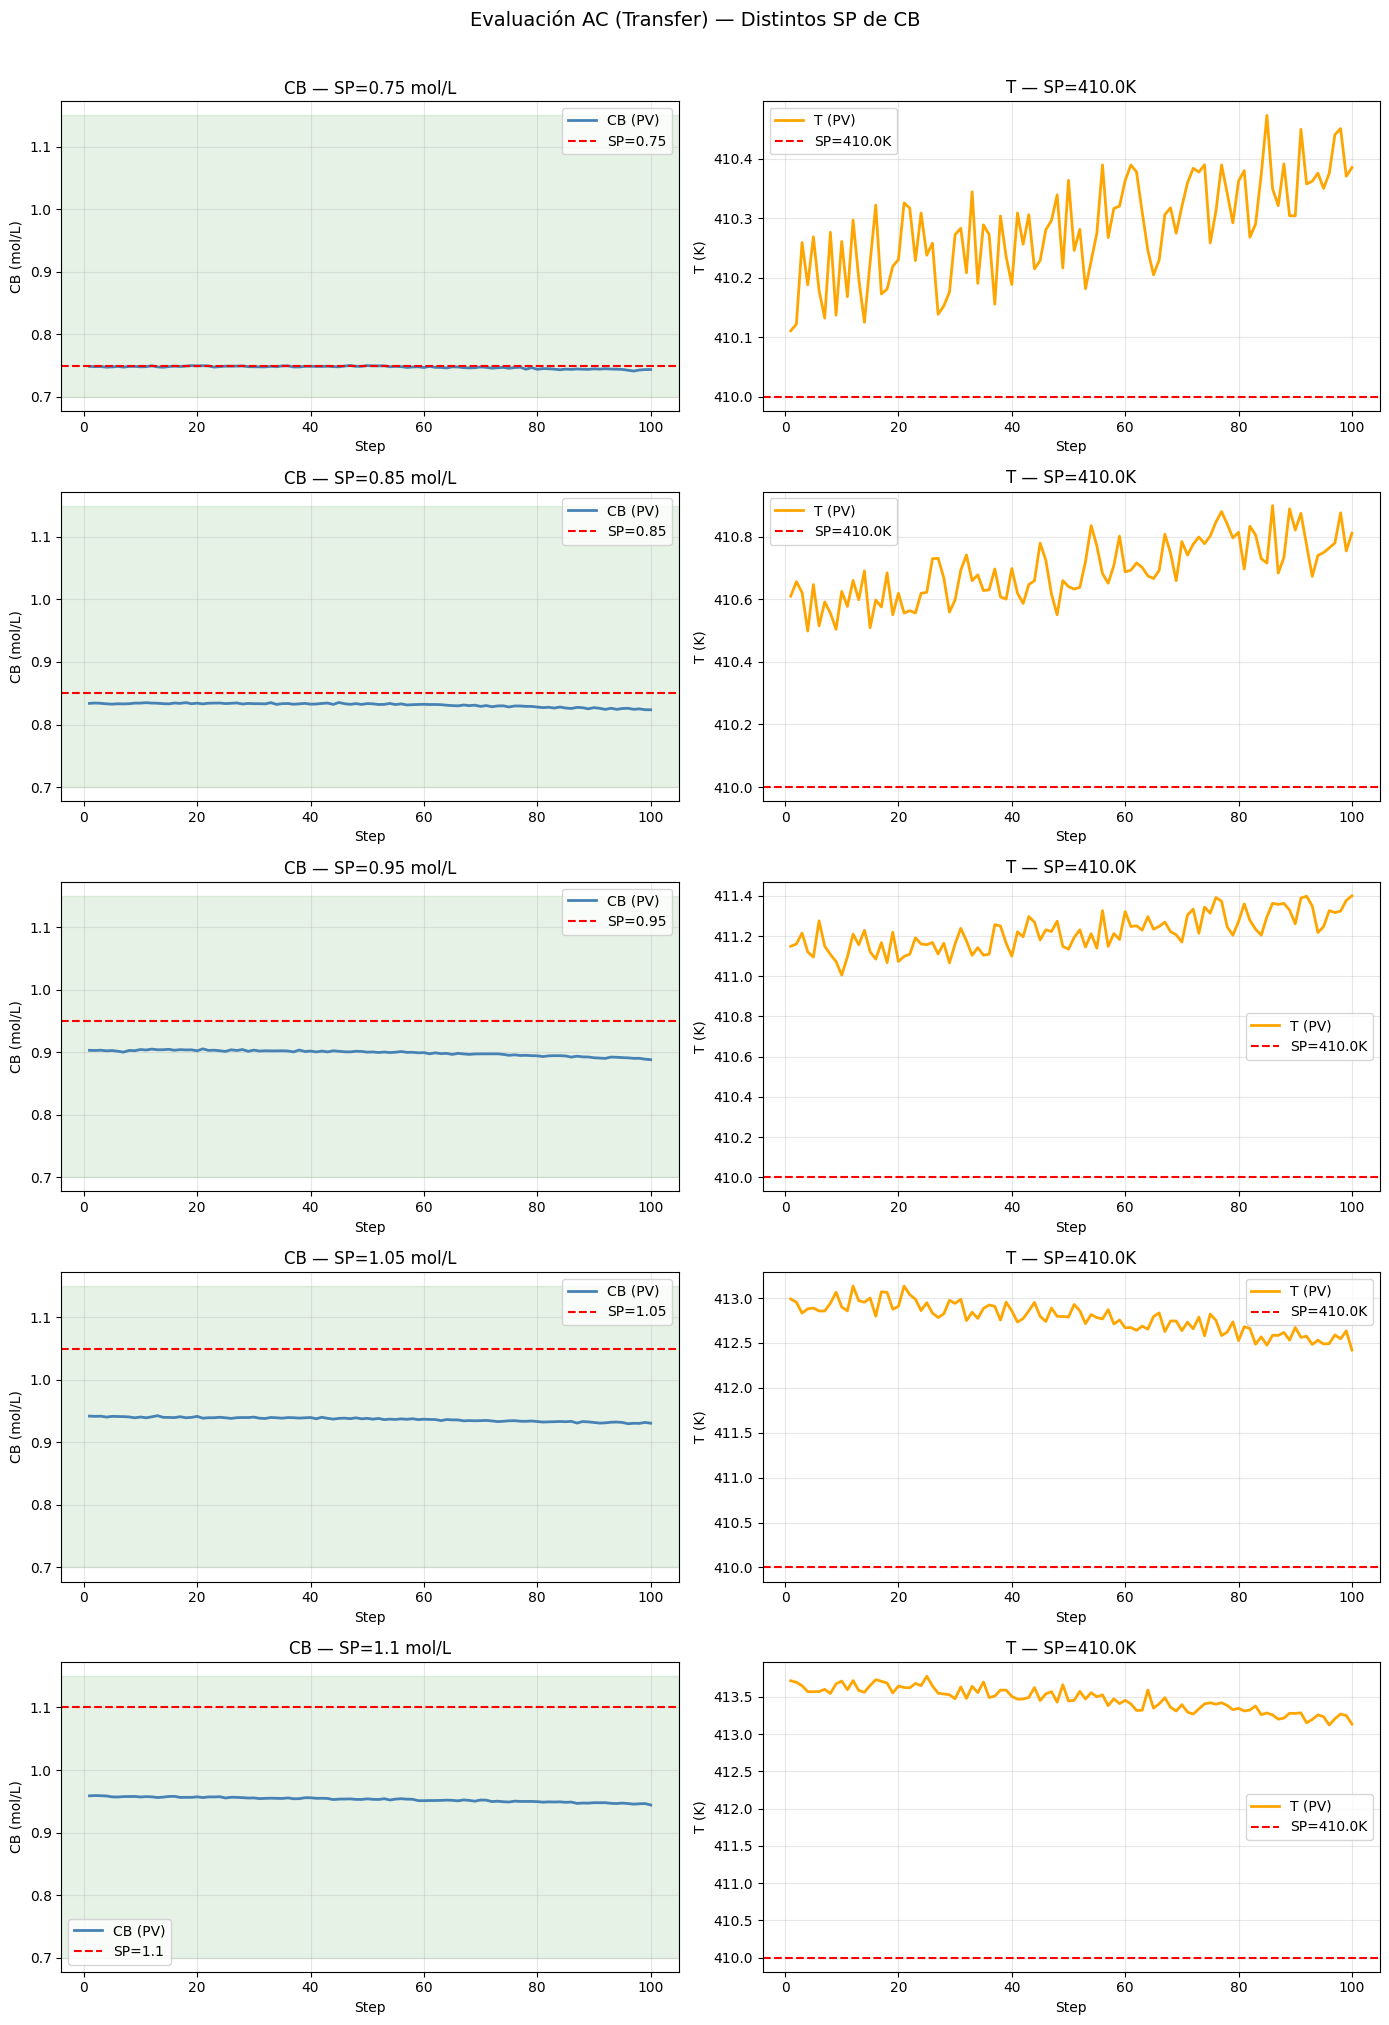

In [24]:
# ============ EVALUAR Y GRAFICAR ============
fig, axes = plt.subplots(len(CB_setpoints), 2, figsize=(14, 4 * len(CB_setpoints)))

T_fijo = 410.0  # Temperatura fija para variar CB

for i, CB_sp in enumerate(CB_setpoints):
    CB_hist, T_hist = evaluar_sp(trainer_eval, CB_sp, T_fijo)
    steps = np.arange(1, len(CB_hist) + 1)

    ax_CB = axes[i, 0]
    ax_CB.plot(steps, CB_hist, color='steelblue', linewidth=2, label='CB (PV)')
    ax_CB.axhline(CB_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={CB_sp}')
    ax_CB.axhspan(0.7, 1.15, alpha=0.1, color='green')
    ax_CB.set_title(f'CB — SP={CB_sp} mol/L')
    ax_CB.set_xlabel('Step')
    ax_CB.set_ylabel('CB (mol/L)')
    ax_CB.legend()
    ax_CB.grid(True, alpha=0.3)

    ax_T = axes[i, 1]
    ax_T.plot(steps, T_hist, color='orange', linewidth=2, label='T (PV)')
    ax_T.axhline(T_fijo, color='red', linestyle='--', linewidth=1.5, label=f'SP={T_fijo}K')
    ax_T.set_title(f'T — SP={T_fijo}K')
    ax_T.set_xlabel('Step')
    ax_T.set_ylabel('T (K)')
    ax_T.legend()
    ax_T.grid(True, alpha=0.3)

    print(f'CB_sp={CB_sp} → CB_final={CB_hist[-1]:.4f} (err={abs(CB_hist[-1]-CB_sp):.4f}) | '
          f'T_final={T_hist[-1]:.2f} (err={abs(T_hist[-1]-T_fijo):.2f}K)')

plt.suptitle('Evaluación AC (Transfer) — Distintos SP de CB', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eval_transfer_CB_setpoints.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Test de Robustez: Perturbación en CA0

Perturbación: CA0 = 5.5 mol/L


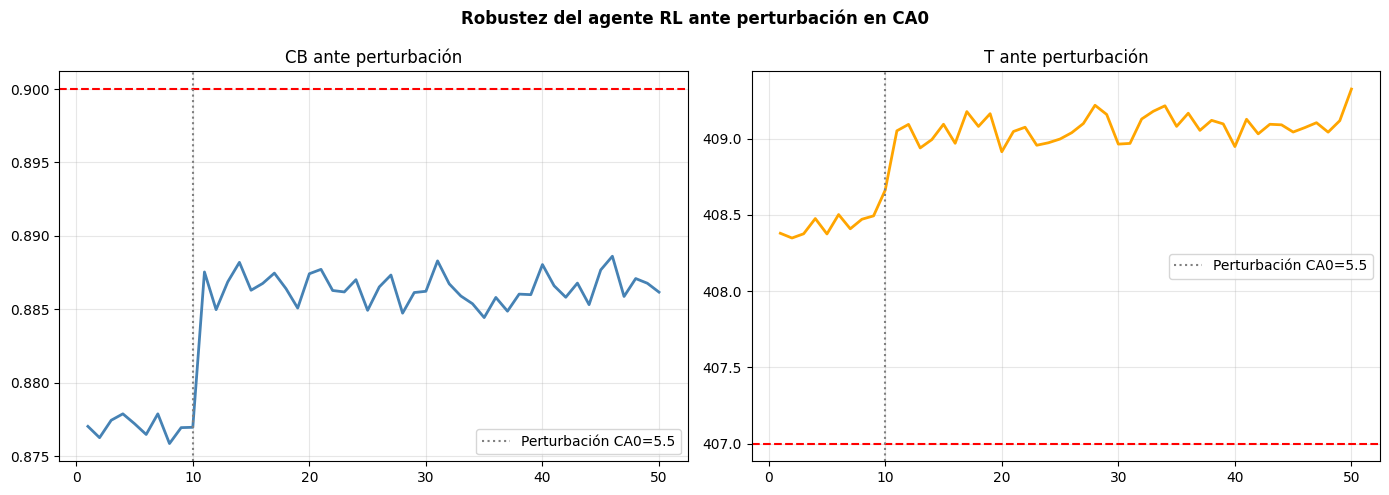

In [25]:
# ============ PERTURBACIÓN: CA0 cambia de 5.1 a 5.5 mol/L ============
# Esto simula un cambio real en la alimentación del reactor.
# Los métodos clásicos NO se adaptan (PID fijo). El agente RL sí.

CB_sp, T_sp = 0.90, 407.0  # Mantener en SS

# --- RL con perturbación ---
state = trainer_eval.env.reset()[0]
trainer_eval.env.manipulable_setpoints = [CB_sp, T_sp]
trainer_eval.env._update_errors()
state = trainer_eval.env._get_observation()

CB_rl, T_rl = [], []
for step in range(50):
    if step == 10:
        reactor_eval2.set_disturbance(CA0=5.5)  # Perturbación en step 10
    action = trainer_eval.agent_ctrl.select_action(state, training=False)
    next_state, _, _, _, _ = trainer_eval.env.step(action)
    CB_rl.append(trainer_eval.env.manipulable_pvs[0])
    T_rl.append(trainer_eval.env.manipulable_pvs[1])
    state = next_state

# --- Graficar ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
steps = np.arange(1, len(CB_rl) + 1)

axes[0].plot(steps, CB_rl, color='steelblue', linewidth=2)
axes[0].axhline(CB_sp, color='red', linestyle='--')
axes[0].axvline(10, color='gray', linestyle=':', label='Perturbación CA0=5.5')
axes[0].set_title('CB ante perturbación')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, T_rl, color='orange', linewidth=2)
axes[1].axhline(T_sp, color='red', linestyle='--')
axes[1].axvline(10, color='gray', linestyle=':', label='Perturbación CA0=5.5')
axes[1].set_title('T ante perturbación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Robustez del agente RL ante perturbación en CA0', fontweight='bold')
plt.tight_layout()
plt.savefig('robustez_perturbacion_CA0.png', dpi=150, bbox_inches='tight')
plt.show()

Perturbación: CA0 = 5.5 mol/L


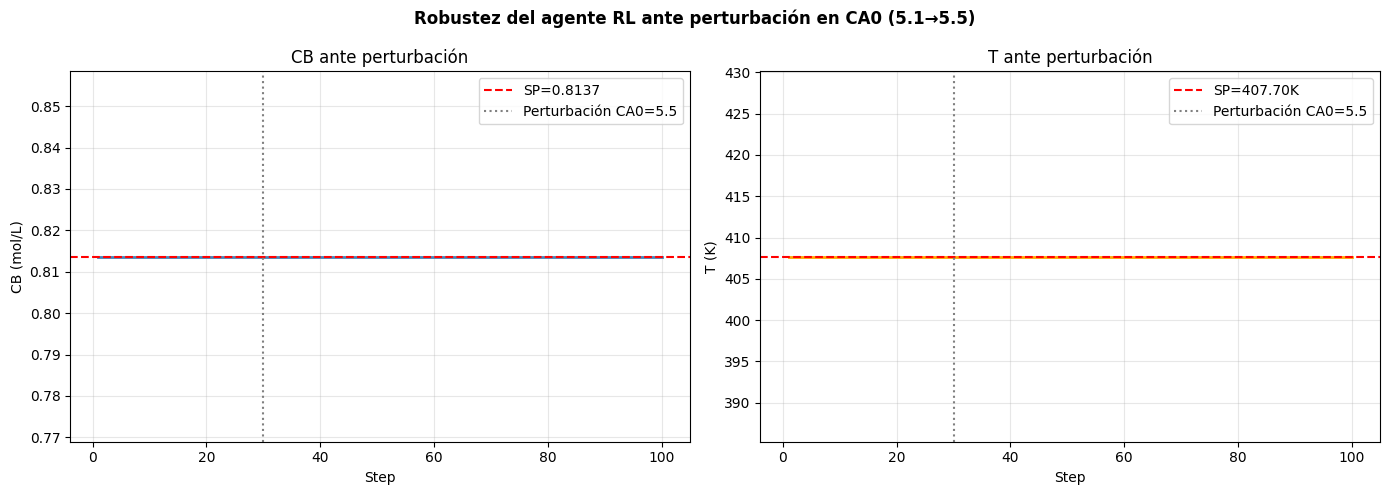

In [26]:
CB_sp, T_sp = reactor_eval2.CB_ss, reactor_eval2.T_ss  # Arrancar en SS exacto

state = trainer_eval.env.reset()[0]
trainer_eval.env.manipulable_setpoints = [CB_sp, T_sp]
trainer_eval.env._update_errors()
state = trainer_eval.env._get_observation()

CB_rl, T_rl = [], []
for step in range(100):  # Más steps para ver la recuperación
    if step == 30:  # Perturbación más tarde, cuando ya está estable
        reactor_eval2.set_disturbance(CA0=5.5)
    action = trainer_eval.agent_ctrl.select_action(state, training=False)
    next_state, _, _, _, _ = trainer_eval.env.step(action)
    CB_rl.append(trainer_eval.env.manipulable_pvs[0])
    T_rl.append(trainer_eval.env.manipulable_pvs[1])
    state = next_state

# --- Graficar ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
steps = np.arange(1, len(CB_rl) + 1)

axes[0].plot(steps, CB_rl, color='steelblue', linewidth=2)
axes[0].axhline(CB_sp, color='red', linestyle='--', label=f'SP={CB_sp:.4f}')
axes[0].axvline(30, color='gray', linestyle=':', label='Perturbación CA0=5.5')
axes[0].set_title('CB ante perturbación')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('CB (mol/L)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, T_rl, color='orange', linewidth=2)
axes[1].axhline(T_sp, color='red', linestyle='--', label=f'SP={T_sp:.2f}K')
axes[1].axvline(30, color='gray', linestyle=':', label='Perturbación CA0=5.5')
axes[1].set_title('T ante perturbación')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('T (K)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Robustez del agente RL ante perturbación en CA0 (5.1→5.5)', fontweight='bold')
plt.tight_layout()
plt.savefig('robustez_perturbacion_CA0_v2.png', dpi=150, bbox_inches='tight')
plt.show()

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
Perturbación: CA0 = 5.5 mol/L


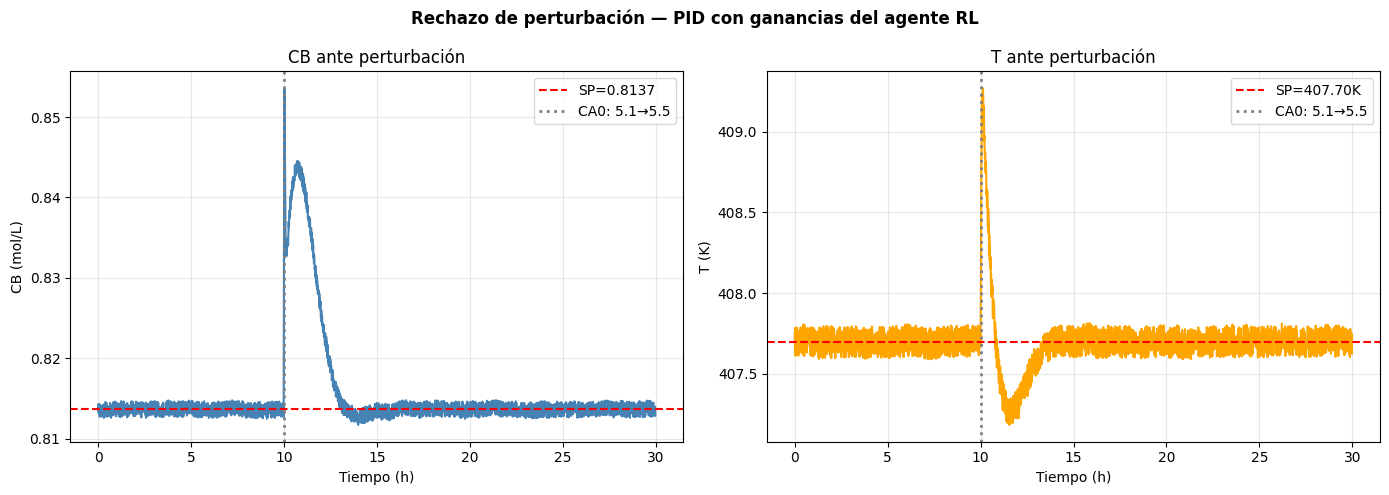

In [27]:
# ============ TEST DE ROBUSTEZ — LOOP DIRECTO ============
reactor_rob = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))
reactor_rob.reset()

pid_controllers = [
    PIDController(kp=50.0, ki=500.0, kd=0.01, dt=DT, output_limits=ACTUATOR_LIMITS[0]),
    PIDController(kp=10.0, ki=1000.0, kd=0.0,  dt=DT, output_limits=ACTUATOR_LIMITS[1]),
]
pid_controllers[0].integral = reactor_rob.v_ss / pid_controllers[0].ki
pid_controllers[1].integral = reactor_rob.QK_ss / pid_controllers[1].ki

CB_sp = reactor_rob.CB_ss
T_sp = reactor_rob.T_ss

N_STEPS = 3000  # 30 horas
PERTURB_STEP = 1000  # Perturbación a las 10 horas

cb_hist, t_hist = [], []

for step in range(N_STEPS):
    if step == PERTURB_STEP:
        reactor_rob.set_disturbance(CA0=5.5)

    meas = reactor_rob.get_measurements()
    v_out = pid_controllers[0].compute(setpoint=CB_sp, process_value=meas['CB'])
    qk_out = pid_controllers[1].compute(setpoint=T_sp, process_value=meas['T'])
    pvs = reactor_rob.simulate_step_multi([v_out, qk_out], DT)
    cb_hist.append(pvs[0])
    t_hist.append(pvs[1])

# --- Graficar ---
time_h = np.arange(N_STEPS) * DT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(time_h, cb_hist, color='steelblue', linewidth=1.5)
axes[0].axhline(CB_sp, color='red', linestyle='--', label=f'SP={CB_sp:.4f}')
axes[0].axvline(PERTURB_STEP * DT, color='gray', linestyle=':', linewidth=2, label='CA0: 5.1→5.5')
axes[0].set_title('CB ante perturbación')
axes[0].set_xlabel('Tiempo (h)')
axes[0].set_ylabel('CB (mol/L)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_h, t_hist, color='orange', linewidth=1.5)
axes[1].axhline(T_sp, color='red', linestyle='--', label=f'SP={T_sp:.2f}K')
axes[1].axvline(PERTURB_STEP * DT, color='gray', linestyle=':', linewidth=2, label='CA0: 5.1→5.5')
axes[1].set_title('T ante perturbación')
axes[1].set_xlabel('Tiempo (h)')
axes[1].set_ylabel('T (K)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Rechazo de perturbación — PID con ganancias del agente RL', fontweight='bold')
plt.tight_layout()
plt.savefig('robustez_perturbacion_loop_directo.png', dpi=150, bbox_inches='tight')
plt.show()